In [2]:
import numpy as np
from qutip import *
import matplotlib.pyplot as plt
from typing import Union
from qutip import basis

In [3]:
#parameters
omega_c = 2 * np.pi * 50 #MHz
omega_t = 2 * np.pi * 25 #MHz
T_t = 1 * np.pi/omega_t
T_c = 1 * np.pi/omega_c
tmax = T_c * 2 + T_t * 3
V_dd = 2 * np.pi * 0 #MHz
tau_c = 548
tau_R = 505
gamma_c = 1/tau_c
gamma_R = 1/tau_R

In [4]:
tmax

0.08

In [5]:
#time list
tlist = np.linspace(0, tmax, 1000)

#control atom states
gc = basis(2,0) #|0>
rc = basis(2,1) #|1>

#dagger
gc_dag = gc.dag()  # <0|
rc_dag = rc.dag()  # <1|

#target atom states
gt = basis(3,0) 
et = basis(3,1)
rt = basis(3,2)

#dagger
gt_dag = gt.dag()
et_dag = et.dag()
rt_dag = rt.dag()

In [6]:
#control field
def Omega_c(t):
    if 0<=t<T_c:
        return omega_c/2
    elif T_c + 3 * T_t < t <= tmax:
        return - omega_c/2
    else:
        return 0

In [ ]:
#target atoms
def Omega_p(t):
    if T_c<=t<T_c+T_t:
        return omega_t/2
    elif T_c + 2 * T_t <= t <= T_c + 3 * T_t:
        return omega_t/2
    else:
        return 0


def Omega_p2(t):
    if T_c + T_t <= t <= T_c + 2 * T_t:
        return - omega_t/2
    else:
        return 0
    

#def ht(t):
#    return Omega_p(t)/2 * (rt * et_dag + et * rt_dag)

#def ht2(t):
#    return Omega_p2(t)/2 * (rt * gt_dag + gt * rt_dag)

#def hc(t):
#    return Omega_c(t)/2 * (gc * rc_dag + rc * gc_dag)


/tmp/ipykernel_530325/1320722229.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


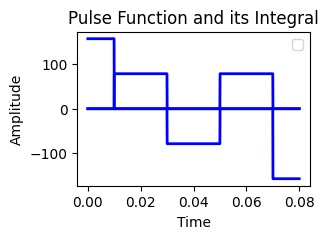

In [11]:
# 可视化函数和积分
t_plot = np.linspace(0, tmax, 1000)
pulse_valuesp = [Omega_p(t) for t in t_plot]
pulse_valuesp2 = [Omega_p2(t) for t in t_plot]
pulse_valuesc = [Omega_c(t) for t in t_plot]

plt.figure(figsize=(3, 2))
plt.plot(t_plot, pulse_valuesp, 'b-', linewidth=2)
plt.plot(t_plot, pulse_valuesp2, 'b-', linewidth=2)
plt.plot(t_plot, pulse_valuesc, 'b-', linewidth=2)


plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Pulse Function and its Integral')
plt.legend()
plt.grid(False)
plt.show()

In [12]:
#hc = np.array([[0, 0, 0],
#               [0, 0, omega_c/2],
#               [0, omega_c/2, 0]])

#hrr = np.array([[0, 0, 0],
#                [0, 0, 0],
#                [0, 0, 1]])

#hRR = np.array([[0, 0, 0, 0],
#                [0, 0, 0, 0],
#                [0, 0, 0, 0],
#                [0, 0, 0, 1]])

#hamiltonian
hc_op = gc * rc_dag + rc * gc_dag
ht_op = rt * et_dag + et * rt_dag
ht2_op = rt * gt_dag + gt * rt_dag
hrr_op = rc * rc_dag
hRR_op = rt * rt_dag

Hc_op = tensor(hc_op, Qobj(np.eye(3)))
Ht_op1 = tensor(Qobj(np.eye(2)), ht_op)
Ht_op2 = tensor(Qobj(np.eye(2)), ht2_op)

HRr = V_dd * tensor(hrr_op, hRR_op)

/tmp/ipykernel_530325/1320722229.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


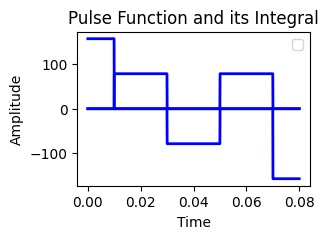

In [ ]:
L_c = np.sqrt(gamma_c) * (gc * rc_dag)
L_R = np.sqrt(gamma_R) * (gt * rt_dag)

h_L1 = -1j/2 * (L_c.dag() * L_c)
h_L2 = -1j/2 * (L_R.dag() * L_R)

H_L = tensor(h_L1, Qobj(np.eye(3))) + tensor(Qobj(np.eye(2)), h_L2)

In [ ]:
Hnhermitian = [H_L, HRr, [Hc_op,Omega_c], [Ht_op1, Omega_p], [Ht_op2, Omega_p2]]


In [169]:
Hnhermitian(0.01)

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j         78.53981634+0.j
   0.        +0.j          0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j         78.53981634+0.j          0.        -0.0009901j
   0.        +0.j          0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
   0.        -0.00091241j  0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.        -0.00091241j 78.53981634+0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j         78.53981634+0.j          0.        -0.00190251j]]

In [170]:
c_ops = tensor(L_c, Qobj(np.eye(3))) + tensor(Qobj(np.eye(2)), L_R)

In [171]:
c_ops

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0.         0.         0.04449942 0.04271788 0.         0.        ]
 [0.         0.         0.         0.         0.04271788 0.        ]
 [0.         0.         0.         0.         0.         0.04271788]
 [0.         0.         0.         0.         0.         0.04449942]
 [0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.        ]]

In [172]:
psi00 = tensor(gc,gt)
psi11 = tensor(gc,et)
psi_0 = tensor(Qobj(np.eye(2)),gt)
psi_1 = tensor(Qobj(np.eye(2)),et)
psi_2 = tensor(Qobj(np.eye(2)),rt)


In [173]:
mc = mcsolve(Hnhermitian, psi00, tlist, c_ops, [psi_0*psi_0.dag(), psi_1*psi_1.dag(), psi_2*psi_2.dag()])

10.0%. Run time:  12.25s. Est. time left: 00:00:01:50
20.0%. Run time:  24.79s. Est. time left: 00:00:01:39
30.0%. Run time:  37.75s. Est. time left: 00:00:01:28
40.0%. Run time:  50.16s. Est. time left: 00:00:01:15
50.0%. Run time:  62.59s. Est. time left: 00:00:01:02
60.0%. Run time:  75.02s. Est. time left: 00:00:00:50
70.0%. Run time:  87.39s. Est. time left: 00:00:00:37
80.0%. Run time: 100.11s. Est. time left: 00:00:00:25
90.0%. Run time: 113.12s. Est. time left: 00:00:00:12
100.0%. Run time: 125.84s. Est. time left: 00:00:00:00
Total run time: 126.16s


In [174]:
mc1 = mcsolve(Hnhermitian, psi11, tlist, c_ops, [psi_0*psi_0.dag(), psi_1*psi_1.dag(), psi_2*psi_2.dag()])

10.0%. Run time:  11.79s. Est. time left: 00:00:01:46
20.0%. Run time:  23.85s. Est. time left: 00:00:01:35
30.0%. Run time:  35.95s. Est. time left: 00:00:01:23
40.0%. Run time:  48.30s. Est. time left: 00:00:01:12
50.0%. Run time:  60.79s. Est. time left: 00:00:01:00
60.0%. Run time:  73.15s. Est. time left: 00:00:00:48
70.0%. Run time:  85.78s. Est. time left: 00:00:00:36
80.0%. Run time:  98.18s. Est. time left: 00:00:00:24
90.0%. Run time: 110.49s. Est. time left: 00:00:00:12
100.0%. Run time: 122.89s. Est. time left: 00:00:00:00
Total run time: 123.16s


In [175]:
print(mc.expect[0][999])
print(mc1.expect[1][999])


6.075769698519662e-10
6.539667552028436e-10


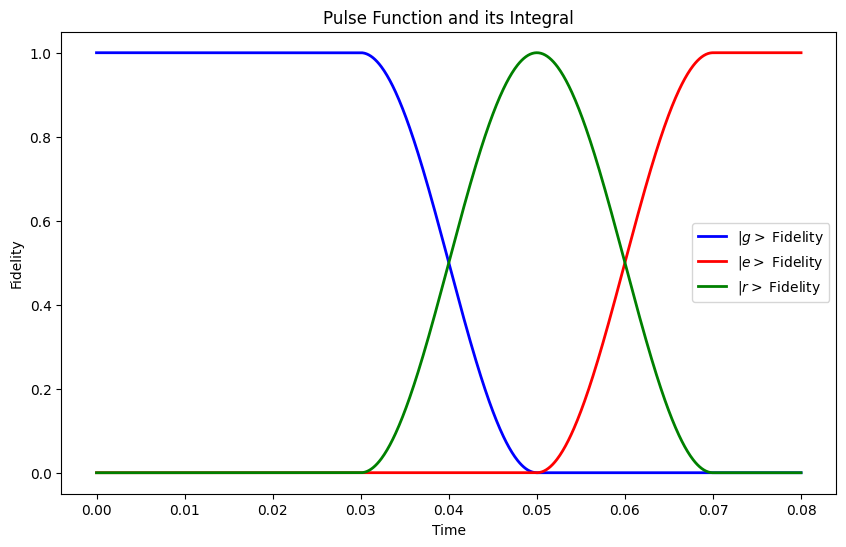

In [176]:
plt.figure(figsize=(10, 6))

plt.plot(tlist,mc.expect[0],'-b',lw=2,label='$|g>$ Fidelity')

plt.plot(tlist,mc.expect[1],'-r',lw=2,label='$|e>$ Fidelity')

plt.plot(tlist,mc.expect[2],'-g',lw=2,label='$|r>$ Fidelity')

plt.xlabel('Time')
plt.ylabel('Fidelity')
plt.title('Pulse Function and its Integral')
plt.legend()
plt.grid(False)
plt.show()
plt.show()

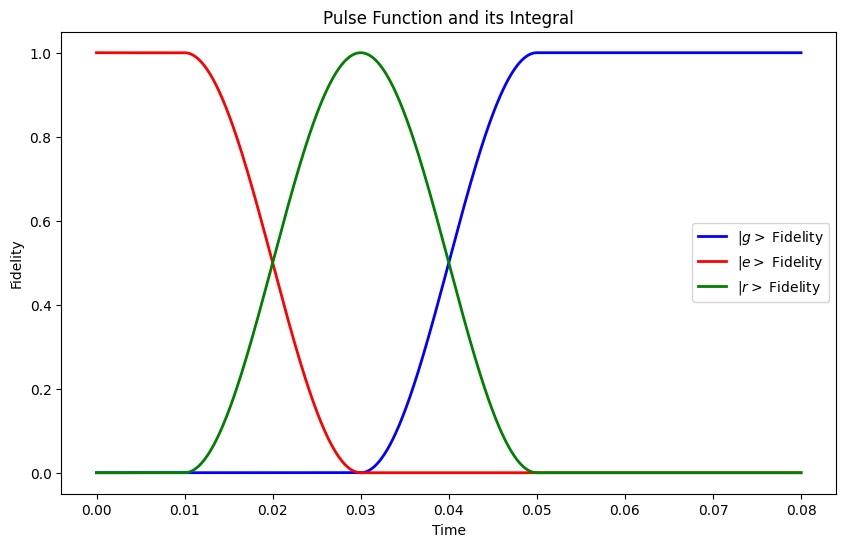

In [177]:
plt.figure(figsize=(10, 6))

plt.plot(tlist,mc1.expect[0],'-b',lw=2,label='$|g>$ Fidelity')

plt.plot(tlist,mc1.expect[1],'-r',lw=2,label='$|e>$ Fidelity')

plt.plot(tlist,mc1.expect[2],'-g',lw=2,label='$|r>$ Fidelity')

plt.xlabel('Time')
plt.ylabel('Fidelity')
plt.title('Pulse Function and its Integral')
plt.legend()
plt.grid(False)
plt.show()
plt.show()